<a href="https://colab.research.google.com/github/Nikhil0264/Collab_special/blob/main/TFOD2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import tensorflow as tf
import tensorflow_hub as hub

import matplotlib.pyplot as plt
import tempfile
from six.moves.urllib.request import urlopen
from six import BytesIO

# COCO label map for object detection models
# Source: https://github.com/tensorflow/models/blob/master/research/object_detection/data/mscoco_label_map.pbtxt
category_index = {
    1: {'id': 1, 'name': 'person'},
    2: {'id': 2, 'name': 'bicycle'},
    3: {'id': 3, 'name': 'car'},
    4: {'id': 4, 'name': 'motorcycle'},
    5: {'id': 5, 'name': 'airplane'},
    6: {'id': 6, 'name': 'bus'},
    7: {'id': 7, 'name': 'train'},
    8: {'id': 8, 'name': 'truck'},
    9: {'id': 9, 'name': 'boat'},
    10: {'id': 10, 'name': 'traffic light'},
    11: {'id': 11, 'name': 'fire hydrant'},
    13: {'id': 13, 'name': 'stop sign'},
    14: {'id': 14, 'name': 'parking meter'},
    15: {'id': 15, 'name': 'bench'},
    16: {'id': 16, 'name': 'bird'},
    17: {'id': 17, 'name': 'cat'},
    18: {'id': 18, 'name': 'dog'},
    19: {'id': 19, 'name': 'horse'},
    20: {'id': 20, 'name': 'sheep'},
    21: {'id': 21, 'name': 'cow'},
    22: {'id': 22, 'name': 'elephant'},
    23: {'id': 23, 'name': 'bear'},
    24: {'id': 24, 'name': 'zebra'},
    25: {'id': 25, 'name': 'giraffe'},
    27: {'id': 27, 'name': 'backpack'},
    28: {'id': 28, 'name': 'umbrella'},
    31: {'id': 31, 'name': 'handbag'},
    32: {'id': 32, 'name': 'tie'},
    33: {'id': 33, 'name': 'suitcase'},
    34: {'id': 34, 'name': 'frisbee'},
    35: {'id': 35, 'name': 'skis'},
    36: {'id': 36, 'name': 'snowboard'},
    37: {'id': 37, 'name': 'sports ball'},
    38: {'id': 38, 'name': 'kite'},
    39: {'id': 39, 'name': 'baseball bat'},
    40: {'id': 40, 'name': 'baseball glove'},
    41: {'id': 41, 'name': 'skateboard'},
    42: {'id': 42, 'name': 'surfboard'},
    43: {'id': 43, 'name': 'tennis racket'},
    44: {'id': 44, 'name': 'bottle'},
    46: {'id': 46, 'name': 'wine glass'},
    47: {'id': 47, 'name': 'cup'},
    48: {'id': 48, 'name': 'fork'},
    49: {'id': 49, 'name': 'knife'},
    50: {'id': 50, 'name': 'spoon'},
    51: {'id': 51, 'name': 'bowl'},
    52: {'id': 52, 'name': 'banana'},
    53: {'id': 53, 'name': 'apple'},
    54: {'id': 54, 'name': 'sandwich'},
    55: {'id': 55, 'name': 'orange'},
    56: {'id': 56, 'name': 'broccoli'},
    57: {'id': 57, 'name': 'carrot'},
    58: {'id': 58, 'name': 'hot dog'},
    59: {'id': 59, 'name': 'pizza'},
    60: {'id': 60, 'name': 'donut'},
    61: {'id': 61, 'name': 'cake'},
    62: {'id': 62, 'name': 'chair'},
    63: {'id': 63, 'name': 'couch'},
    64: {'id': 64, 'name': 'potted plant'},
    65: {'id': 65, 'name': 'bed'},
    67: {'id': 67, 'name': 'dining table'},
    70: {'id': 70, 'name': 'toilet'},
    72: {'id': 72, 'name': 'tv'},
    73: {'id': 73, 'name': 'laptop'},
    74: {'id': 74, 'name': 'mouse'},
    75: {'id': 75, 'name': 'remote'},
    76: {'id': 76, 'name': 'keyboard'},
    77: {'id': 77, 'name': 'cell phone'},
    78: {'id': 78, 'name': 'microwave'},
    79: {'id': 79, 'name': 'oven'},
    80: {'id': 80, 'name': 'toaster'},
    81: {'id': 81, 'name': 'sink'},
    82: {'id': 82, 'name': 'refrigerator'},
    84: {'id': 84, 'name': 'book'},
    85: {'id': 85, 'name': 'clock'},
    86: {'id': 86, 'name': 'vase'},
    87: {'id': 87, 'name': 'scissors'},
    88: {'id': 88, 'name': 'teddy bear'},
    89: {'id': 89, 'name': 'hair drier'},
    90: {'id': 90, 'name': 'toothbrush'},
}

In [2]:
import numpy as np
from PIL import Image
from PIL import ImageColor
from PIL import ImageDraw
from PIL import ImageFont
from PIL import ImageOps

import time

In [34]:
def display_image(image):
  fig = plt.figure(figsize=(20,15))
  plt.grid(False)
  plt.imshow(image)


def download_and_resize(url,new_width=256,new_height=256,display=False):
  _,filename = tempfile.mkstemp(suffix='jpg')
  response = urlopen(url)
  image_data = response.read()
  image_data = BytesIO(image_data)
  pil_image = Image.open(image_data)
  pil_image = ImageOps.fit(pil_image,(new_width,new_height),Image.LANCZOS)
  pil_image_rgb = pil_image.convert("RGB")
  pil_image_rgb.save(filename,format="JPEG",quality=90)
  print("Image downloaded to %s." % filename)
  if display:
    display_image(pil_image)
  return filename


def draw_bounding_box_on_image(image,ymin,xmin,ymax,xmax,color,font,thickness=4,display_str_list=()):
  draw = ImageDraw.Draw(image)
  im_width,im_height = image.size
  (left,right,top,bottom) = (xmin*im_width,xmax*im_width,ymin*im_height,ymax*im_height)
  draw.line([(left,top),(left,bottom),(right,bottom),(right,top),(left,top)],width=thickness,fill=color)

  # Correct calculation of text height from bbox
  display_str_heights = [(font.getbbox(ds)[3] - font.getbbox(ds)[1]) for ds in display_str_list]

  total_display_str_height = (1+2*0.05)*sum(display_str_heights)
  if top>total_display_str_height:
    text_bottom = top
  else:
    text_bottom = top + total_display_str_height

  for display_str in display_str_list[::-1]:
    bbox = font.getbbox(display_str)
    # Correct calculation of text_width and text_height
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    margin = np.ceil(0.05*text_height)
    draw.rectangle([(left,text_bottom-text_height-2*margin),(left+text_width,text_bottom)],fill=color)
    draw.text((left+margin,text_bottom-text_height-margin),display_str,fill="black",font=font)
    text_bottom -= text_height-2*margin

def draw_boxes(image,boxes,class_names,scores,max_boxes=10,min_score=0.1):
  colors = list(ImageColor.colormap.values())
  font = ImageFont.load_default()

  for i in range(min(boxes.shape[0],max_boxes)):
    if (scores[i] >= min_score):
      ymin,xmin,ymax,xmax = tuple(boxes[i])
      display_str = "{}: {}%".format(class_names[i].decode("ascii"),int(100*scores[i]))
      color = colors[hash(class_names[i]) % len(colors)]
      image_pil = Image.fromarray(np.uint8(image)).convert("RGB")
      draw_bounding_box_on_image(image_pil,ymin,xmin,ymax,xmax,color,font,display_str_list=[display_str])
      np.copyto(image,np.array(image_pil))
  return image

In [37]:
image_url = "https://www.nasa.gov/sites/default/files/thumbnails/image/main_image_star-forming_region_carina_nircam_final-5mb.jpg"
print(f"Using new image URL: {image_url}")

Using new image URL: https://www.nasa.gov/sites/default/files/thumbnails/image/main_image_star-forming_region_carina_nircam_final-5mb.jpg


Image downloaded to /tmp/tmp4mhdbx9_jpg.
Image downloaded to: /tmp/tmp4mhdbx9_jpg


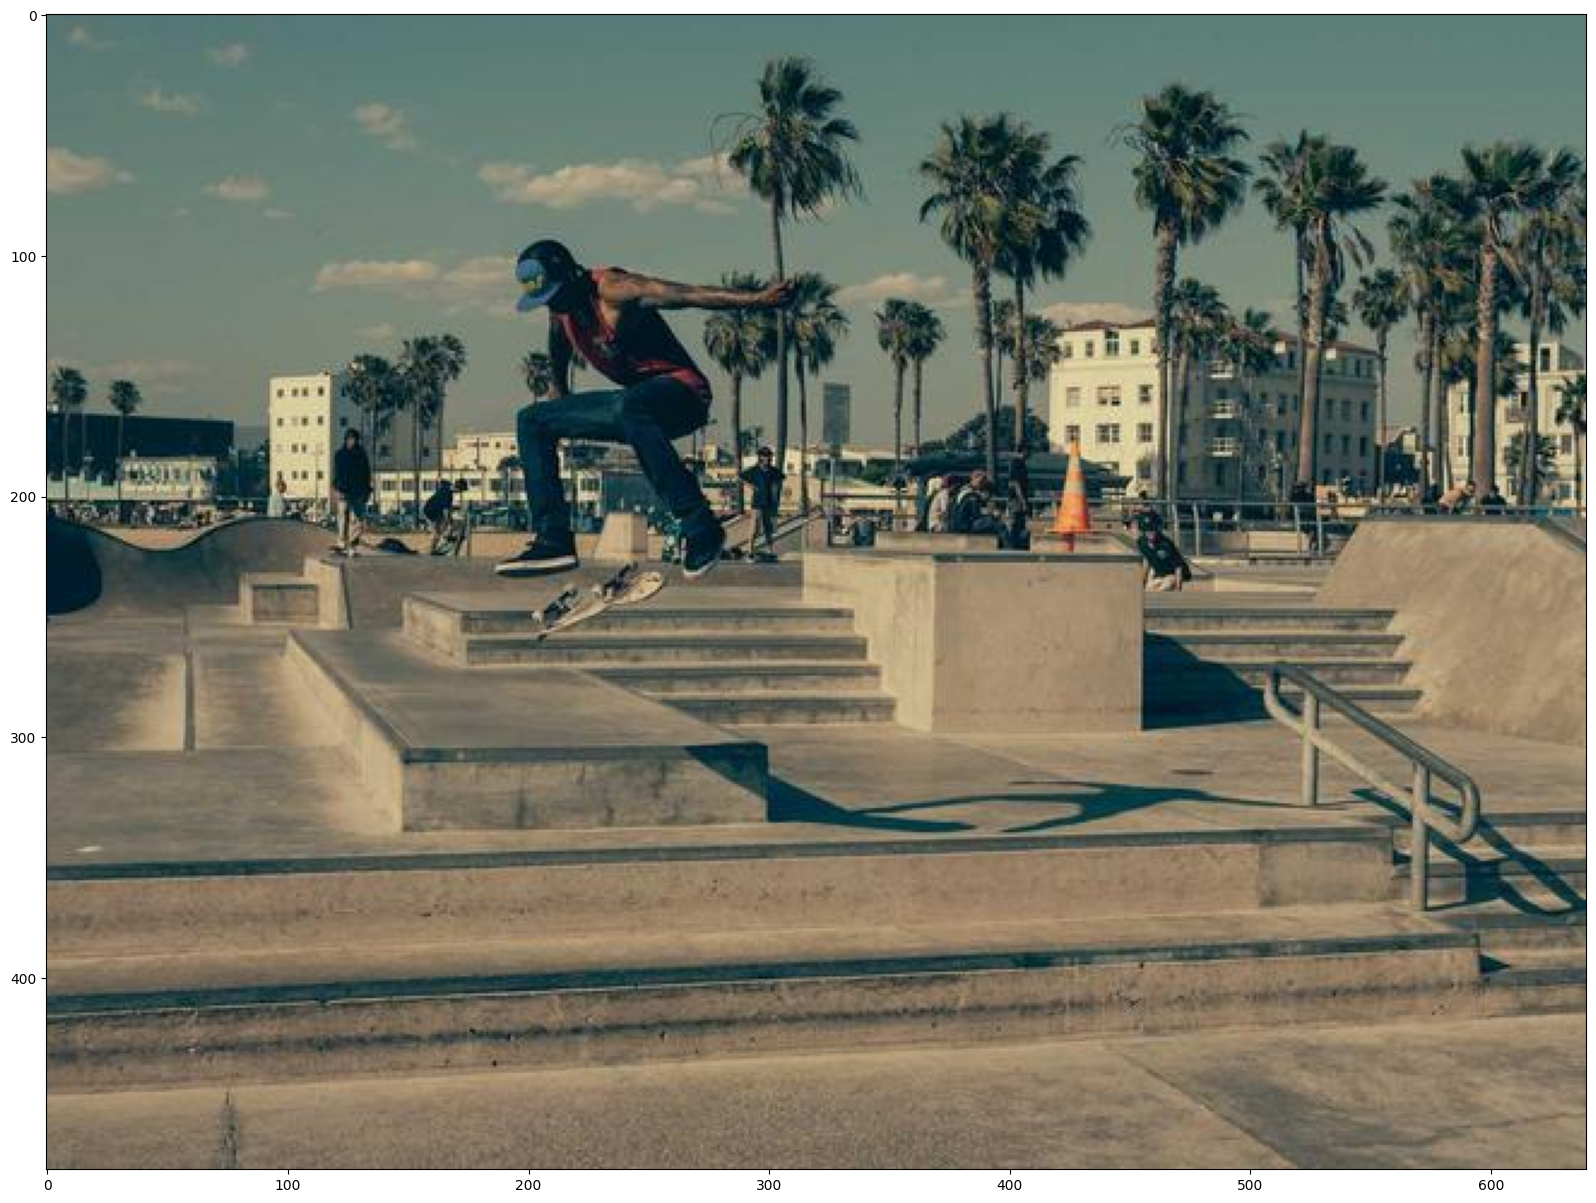

In [38]:
image_url = "https://picsum.photos/640/480"
downloaded_image_path = download_and_resize(image_url, 640, 480,True)
print(f"Image downloaded to: {downloaded_image_path}")

In [39]:
module_handle = "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"

In [40]:
detector = hub.load(module_handle)

In [41]:
def load_img(path):
  img = tf.io.read_file(path)
  img =  tf.image.decode_jpeg(img,channels=3)
  return img

In [46]:
def run_detector(detector,path):
  img = load_img(path)
  converted_img = img[tf.newaxis,...]
  start_time = time.time()
  result = detector(converted_img)
  end_time = time.time()
  result = {key:value.numpy() for key,value in result.items()}

  detection_boxes = result['detection_boxes'][0]
  detection_scores = result['detection_scores'][0]
  detection_classes_numeric = result['detection_classes'][0].astype(int)

  # Use the COCO label map to get meaningful class names
  class_names_for_drawing = [category_index[class_id]['name'].encode('ascii') for class_id in detection_classes_numeric]

  print("Found %d objects" % len(detection_scores))
  print('Inference time', end_time - start_time)

  image_with_boxes = draw_boxes(img.numpy(),
                                detection_boxes,
                                class_names_for_drawing,
                                detection_scores)
  display_image(image_with_boxes)

Found 100 objects
Inference time 3.529780626296997


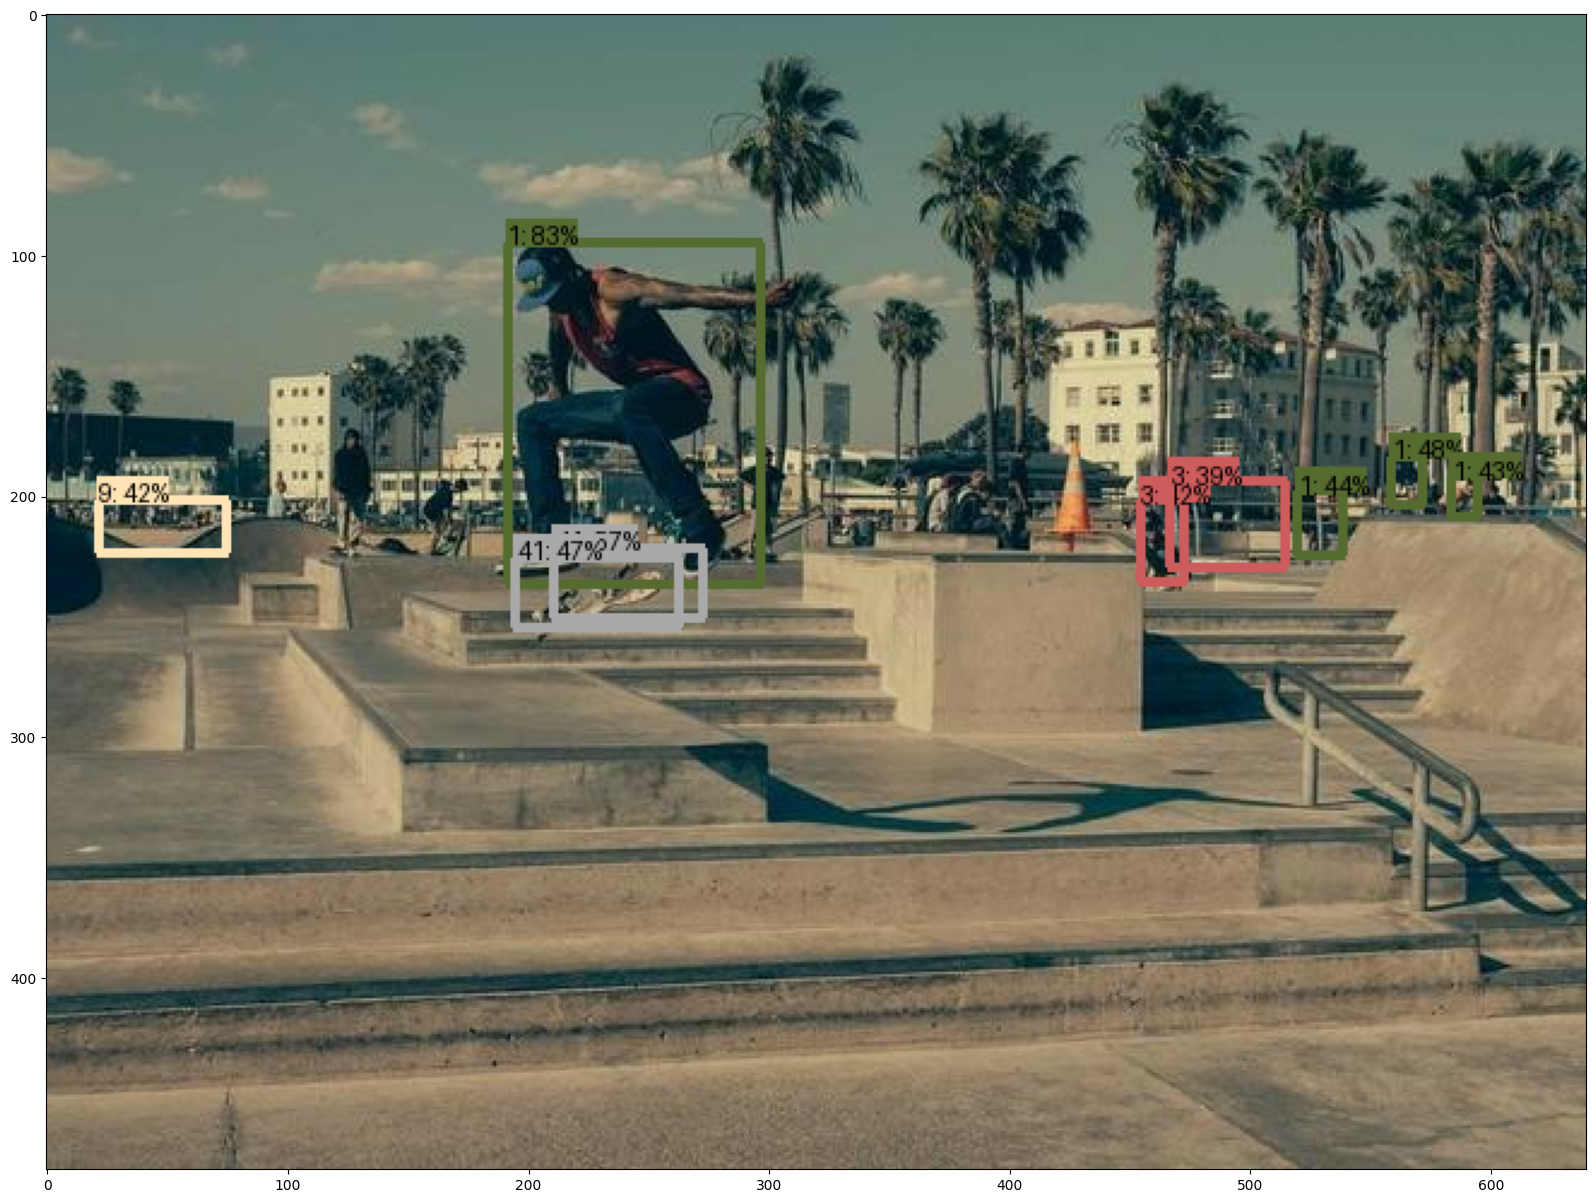

In [43]:
run_detector(detector,downloaded_image_path)